## 2.3.1. Импорты, seed и среда

In [26]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import random
import os

In [27]:
# seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 2.3.2. Данные и первичный анализ

Размер: (4320, 2)
Диапазон: 2025-01-01 00:00:00 - 2025-06-29 23:00:00
Пропуски:
 date      0
target    0
dtype: int64


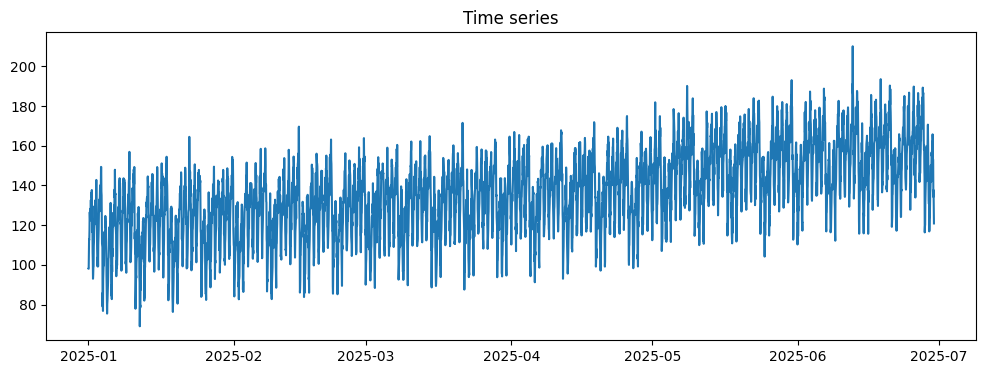

In [28]:
df = pd.read_csv("S12-hw-dataset.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Размер:", df.shape)
print("Диапазон:", df["date"].min(), "-", df["date"].max())
print("Пропуски:\n", df.isna().sum())

plt.figure(figsize=(12,4))
plt.plot(df["date"], df["target"])
plt.title("Time series")
plt.show()

## Возможен тренд
- Возможна сезонность (особенно если hourly данные)
- Проверить выбросы
- Ряд может быть нестационарным

## 2.3.3. Корректный temporal split

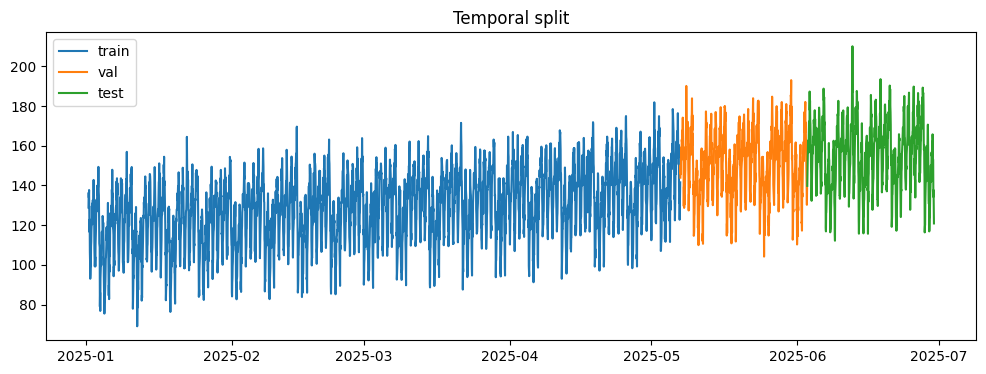

In [29]:
def make_features(df):
    df = df.copy()
    
    df["lag_1"] = df["target"].shift(1)
    df["lag_7"] = df["target"].shift(7)
    df["lag_14"] = df["target"].shift(14)
    
    df["rolling_mean_7"] = df["target"].shift(1).rolling(7).mean()
    df["rolling_std_7"] = df["target"].shift(1).rolling(7).std()
    
    df["day_of_week"] = df["date"].dt.dayofweek
    
    return df

df_feat = make_features(df).dropna().reset_index(drop=True)

n = len(df_feat)

train_end = int(n * 0.7)
val_end = int(n * 0.85)

train = df_feat.iloc[:train_end]
val = df_feat.iloc[train_end:val_end]
test = df_feat.iloc[val_end:]

plt.figure(figsize=(12,4))
plt.plot(train["date"], train["target"], label="train")
plt.plot(val["date"], val["target"], label="val")
plt.plot(test["date"], test["target"], label="test")
plt.legend()
plt.title("Temporal split")
plt.show()

## Почему random split некорректен для временных рядов

- нарушение временной структуры: Random split перемешивает наблюдения, разрушая автокорреляционную структуру ряда.
- утечка будущего: Модель может "увидеть" будущие значения при обучении, что приводит к нереалистично оптимистичным оценкам.
- ошибка валидации: Валидация на перемешанных данных не отражает реальную задачу прогнозирования, где будущее неизвестно.
- практическая неприменимость: В реальных задачах прогнозирования мы всегда имеем дело с хронологическим порядком данных.

## 2.3.4. Признаки для baseline-моделей

In [30]:
FEATURES = [
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7",
    "day_of_week"
]

X_train, y_train = train[FEATURES], train["target"]
X_val, y_val = val[FEATURES], val["target"]
X_test, y_test = test[FEATURES], test["target"]

## 2.3.5. Оконное представление для GRU

In [31]:
class TimeSeriesDataset(Dataset):
    def __init__(self, series, window):
        self.series = series.values
        self.window = window
        
    def __len__(self):
        return len(self.series) - self.window
    
    def __getitem__(self, idx):
        x = self.series[idx:idx+self.window]
        y = self.series[idx+self.window]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [32]:
WINDOW = 24

def make_loader(series):
    ds = TimeSeriesDataset(series, WINDOW)
    return DataLoader(ds, batch_size=32, shuffle=False)

train_loader = make_loader(train["target"])
val_loader = make_loader(val["target"])
test_loader = make_loader(test["target"])

## 2.3.6. Базовые функции обучения и оценки

In [33]:
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

def eval_model_split(y_true, y_pred):
    mae, rmse, mape = compute_metrics(y_true, y_pred)
    return {"mae": mae, "rmse": rmse, "mape": mape}

## 3. Эксперименты

In [34]:
RUNS_PATH = "artifacts/runs.csv"

columns = [
    "experiment_id","task","dataset","seed","split_summary",
    "window_size","horizon","model_summary","features_summary",
    "scaler","optimizer","lr","epochs_trained",
    "best_val_mae","best_val_rmse","best_val_mape",
    "test_mae","test_rmse","test_mape","notes"
]

runs = []

DATASET_NAME = "S12-hw-dataset.csv"
split_summary = f"train={len(train)}, val={len(val)}, test={len(test)}"
horizon = 1
features_summary = "lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7, day_of_week"


def log_run(exp_id, model_summary, val_metrics, test_metrics,
            window_size=None, features="", scaler="none",
            optimizer=None, lr=None, epochs=0):

    runs.append({
        "experiment_id": exp_id,
        "task": "forecasting",
        "dataset": DATASET_NAME,
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": window_size,
        "horizon": horizon,
        "model_summary": model_summary,
        "features_summary": features,
        "scaler": scaler,
        "optimizer": optimizer,
        "lr": lr,
        "epochs_trained": epochs,
        "best_val_mae": val_metrics["mae"],
        "best_val_rmse": val_metrics["rmse"],
        "best_val_mape": val_metrics["mape"],
        "test_mae": test_metrics["mae"],
        "test_rmse": test_metrics["rmse"],
        "test_mape": test_metrics["mape"],
        "notes": ""
    })

In [35]:
# B1 - Naive
val_pred = val["target"].shift(1).dropna()
val_true = val["target"].iloc[1:]

test_pred = test["target"].shift(1).dropna()
test_true = test["target"].iloc[1:]

val_metrics = eval_model_split(val_true, val_pred)
test_metrics = eval_model_split(test_true, test_pred)

log_run("B1", "naive-last", val_metrics, test_metrics, features="last value only")

In [36]:
# B2 - Moving Average
window_ma = 7

val_pred = val["target"].shift(1).rolling(window_ma).mean().dropna()
val_true = val["target"].iloc[window_ma:]

test_pred = test["target"].shift(1).rolling(window_ma).mean().dropna()
test_true = test["target"].iloc[window_ma:]

val_metrics = eval_model_split(val_true, val_pred)
test_metrics = eval_model_split(test_true, test_pred)

log_run("B2", "moving-average", val_metrics, test_metrics,
        window_size=window_ma, features="rolling_mean_7")

In [37]:
# B3 - Ridge
model_ridge = Ridge()
model_ridge.fit(X_train, y_train)

val_metrics = eval_model_split(y_val, model_ridge.predict(X_val))
test_metrics = eval_model_split(y_test, model_ridge.predict(X_test))

log_run("B3", "Ridge", val_metrics, test_metrics,
        features=features_summary, epochs=1)

In [38]:
# R1 - GRU
class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(1, 32, batch_first=True)
        self.fc = nn.Linear(32, 1)
        
    def forward(self, x):
        x = x.unsqueeze(-1)
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze()

In [39]:
model = GRUModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [40]:
def train_epoch(model, loader):
    model.train()
    losses = []
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
    
    return np.mean(losses)

In [41]:
def eval_model(model, loader):
    model.eval()
    preds, targets = [], []
    
    with torch.no_grad():
        for x, y in loader:
            preds.extend(model(x.to(device)).cpu().numpy())
            targets.extend(y.numpy())
    
    return compute_metrics(np.array(targets), np.array(preds))

In [42]:
EPOCHS = 10
best_mae = float("inf")
best_metrics = None
train_losses = []
val_mae_hist = []

for epoch in range(EPOCHS):
    loss = train_epoch(model, train_loader)
    train_losses.append(loss)

    val_mae, val_rmse, val_mape = eval_model(model, val_loader)
    val_mae_hist.append(val_mae)

    if val_mae < best_mae:
        best_mae = val_mae
        best_metrics = {"mae": val_mae, "rmse": val_rmse, "mape": val_mape}
        best_epoch = epoch

        os.makedirs("artifacts", exist_ok=True)
        torch.save(model.state_dict(), "artifacts/best_gru.pt")

        with open("artifacts/best_gru_config.json", "w") as f:
            json.dump({
                "window_size": WINDOW,
                "hidden_size": 32,
                "lr": 1e-3,
                "epochs": EPOCHS,
                "seed": SEED
            }, f, indent=4)

In [43]:
model.load_state_dict(torch.load("artifacts/best_gru.pt"))

test_mae, test_rmse, test_mape = eval_model(model, test_loader)

test_metrics = {"mae": test_mae, "rmse": test_rmse, "mape": test_mape}

log_run("R1", "GRU(hidden=32)", best_metrics, test_metrics,
        window_size=WINDOW, features="raw target windows",
        optimizer="Adam", lr=1e-3, epochs=best_epoch+1)

## Сохранение

In [44]:
os.makedirs("artifacts", exist_ok=True)

runs_df = pd.DataFrame(runs, columns=columns)
runs_df.to_csv(RUNS_PATH, index=False)

runs_df

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,"train=3014, val=646, test=646",NaN,1,naive-last,last value only,none,None,NaN,0,6.449736,8.209363,4.398865,6.345845,8.065991,4.148502,
1,B2,forecasting,S12-hw-dataset.csv,42,"train=3014, val=646, test=646",7.0,1,moving-average,rolling_mean_7,none,None,NaN,0,12.732980,15.263754,8.840080,12.747838,15.257785,8.552955,
2,B3,forecasting,S12-hw-dataset.csv,42,"train=3014, val=646, test=646",NaN,1,Ridge,"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...",none,None,NaN,1,7.166989,8.719938,4.779561,7.312086,9.022839,4.681333,
3,R1,forecasting,S12-hw-dataset.csv,42,"train=3014, val=646, test=646",24.0,1,GRU(hidden=32),raw target windows,none,Adam,0.001,10,120.381516,121.625201,79.694954,125.026222,126.199646,80.326698,


## 4. Артефакты

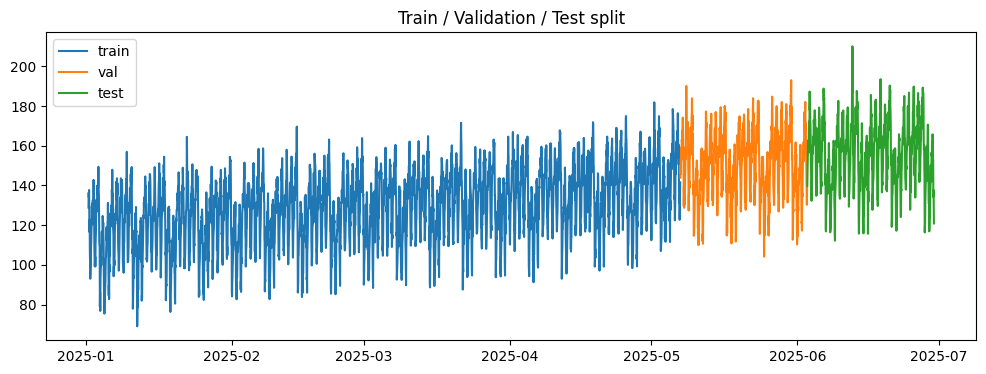

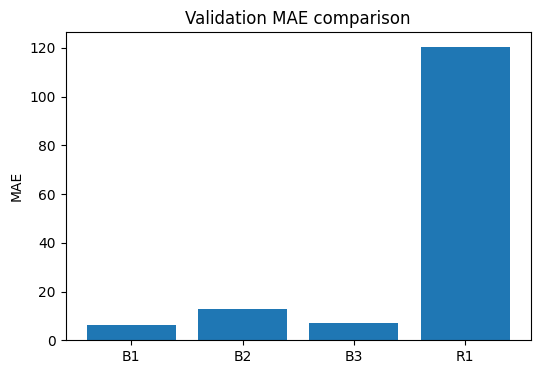

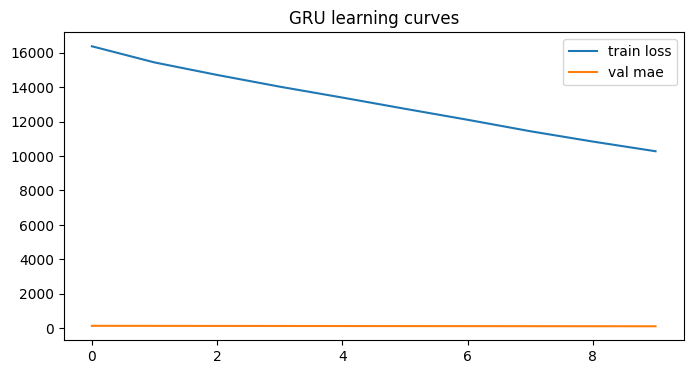

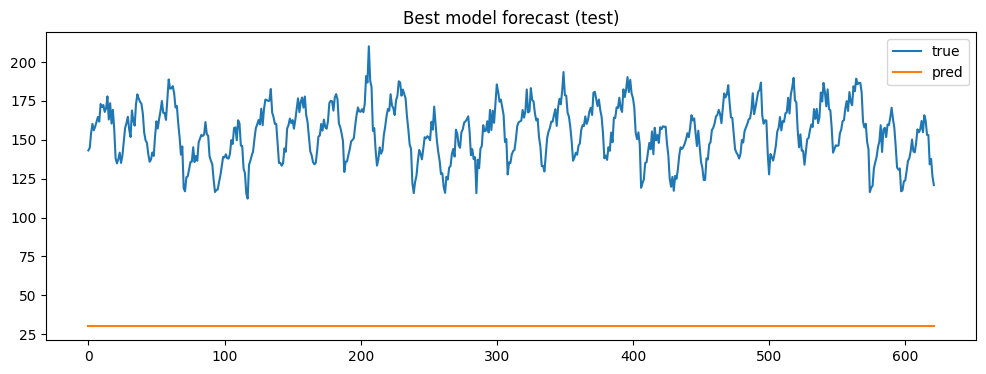

In [45]:
import os
os.makedirs("artifacts/figures", exist_ok=True)


plt.figure(figsize=(12, 4))

plt.plot(train["date"], train["target"], label="train")
plt.plot(val["date"], val["target"], label="val")
plt.plot(test["date"], test["target"], label="test")

plt.legend()
plt.title("Train / Validation / Test split")

plt.savefig("artifacts/figures/series_split.png")
plt.show()


df_plot = runs_df.set_index("experiment_id")

plt.figure(figsize=(6, 4))
plt.bar(df_plot.index, df_plot["best_val_mae"])

plt.title("Validation MAE comparison")
plt.ylabel("MAE")

plt.savefig("artifacts/figures/baselines_compare.png")
plt.show()


plt.figure(figsize=(8, 4))

plt.plot(train_losses, label="train loss")
plt.plot(val_mae_hist, label="val mae")

plt.legend()
plt.title("GRU learning curves")

plt.savefig("artifacts/figures/gru_learning_curves.png")
plt.show()


preds = []
targets = []

model.eval()

with torch.no_grad():
    for x, y in test_loader:
        pred = model(x.to(device)).cpu().numpy()
        preds.extend(pred)
        targets.extend(y.numpy())

plt.figure(figsize=(12, 4))

plt.plot(targets, label="true")
plt.plot(preds, label="pred")

plt.legend()
plt.title("Best model forecast (test)")

plt.savefig("artifacts/figures/best_forecast_test.png")
plt.show()